# FairGate benchmark analysis

Analyze the output of the FairGate load generator and prepare report-ready tables, figures, and notes. The notebook automatically searches both `results/run_*` and `analysis/run_*`; set `RUN_DIR_OVERRIDE` in the setup cell to choose a specific run.

Each run should contain `producer_summary.csv`, `event_latencies.csv`, and `run_config.json`. This notebook requires `pandas` and `matplotlib`. If they are missing, install them in the active kernel with `%pip install pandas matplotlib` and restart the kernel.

**Metric scope:** latency in this dataset is client-observed ACK round-trip time. It is not ClickHouse insert latency. Latency summaries contain only frames for which the generator received and parsed an ACK; interpret them alongside producer errors and rejections.

In [23]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Set a path to analyze a specific run, or leave as None to use the newest run.
# Examples: Path("analysis/run_20261005_193123") or Path("results/run_20261005_193123")
RUN_DIR_OVERRIDE = "run_20261005_193123"

# Locate the repository even when Jupyter starts in analysis/.
search_roots = [Path.cwd(), *Path.cwd().parents]
project_root = next(
    (root for root in search_roots if (root / "go.mod").is_file() and (root / "README.md").is_file()),
    Path.cwd(),
)

if RUN_DIR_OVERRIDE is None:
    candidates = []
    for root in (project_root / "results", project_root / "analysis", project_root):
        if root.is_dir():
            candidates.extend(
                folder for folder in root.glob("run_*")
                if folder.is_dir()
                and (folder / "producer_summary.csv").is_file()
                and (folder / "event_latencies.csv").is_file()
            )
    candidates = list({folder.resolve(): folder for folder in candidates}.values())
    if not candidates:
        raise FileNotFoundError(
            f"No run folder with the required CSV files found under {project_root / 'results'} "
            f"or {project_root / 'analysis'}. Set RUN_DIR_OVERRIDE or copy a generator run there."
        )
    RUN_DIR = max(candidates, key=lambda folder: folder.stat().st_mtime)
else:
    RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser()
    if not RUN_DIR.is_absolute():
        RUN_DIR = (Path.cwd() / RUN_DIR).resolve()

summary_path = RUN_DIR / "producer_summary.csv"
latencies_path = RUN_DIR / "event_latencies.csv"
config_path = RUN_DIR / "run_config.json"
if not summary_path.is_file() or not latencies_path.is_file():
    raise FileNotFoundError(f"{RUN_DIR} must contain producer_summary.csv and event_latencies.csv")

producer = pd.read_csv(summary_path)
events = pd.read_csv(latencies_path)
config = json.loads(config_path.read_text(encoding="utf-8")) if config_path.is_file() else {}

required_producer = {"producer_id", "accepted", "rejected", "errors", "throughput_eps"}
required_events = {"producer_id", "seq", "phase", "profile", "latency_ms", "ack_status"}
missing_producer = required_producer - set(producer.columns)
missing_events = required_events - set(events.columns)
if missing_producer or missing_events:
    raise ValueError(f"Unexpected generator CSV schema. Missing producer columns: {sorted(missing_producer)}; event columns: {sorted(missing_events)}")

for column in ("accepted", "rejected", "errors", "duration_s", "throughput_eps", "p50_ms", "p95_ms", "p99_ms", "anomaly_start", "anomaly_end"):
    if column in producer:
        producer[column] = pd.to_numeric(producer[column], errors="coerce")
for column in ("seq", "latency_ms"):
    events[column] = pd.to_numeric(events[column], errors="coerce")

OUTPUT_DIR = project_root / "analysis" / "reports" / RUN_DIR.name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run: {RUN_DIR}")
print(f"Report output: {OUTPUT_DIR}")
print(f"Generator timestamp: {config.get('timestamp', 'not recorded')}")

Run: /Users/pratyush/GolandProjects/FairGate/analysis/run_20261005_193123
Report output: /Users/pratyush/GolandProjects/FairGate/analysis/reports/run_20261005_193123
Generator timestamp: 2026-10-05T14:01:23.531675+00:00


## Run summary and data quality

The totals below come from the producer summary. ACK latency statistics use rows in the event-level file, so errors without a parsed ACK do not contribute to latency percentiles.

In [24]:
latency = events["latency_ms"].dropna()
accepted = int(producer["accepted"].fillna(0).sum())
rejected = int(producer["rejected"].fillna(0).sum())
errors = int(producer["errors"].fillna(0).sum())
ack_count = accepted + rejected

summary = pd.DataFrame([
    ("Run folder", RUN_DIR.name),
    ("Producers", producer["producer_id"].nunique()),
    ("ACK latency rows", len(latency)),
    ("Accepted ACKs", accepted),
    ("Rejected ACKs", rejected),
    ("Producer errors", errors),
    ("Accepted among ACKed events (%)", round(100 * accepted / ack_count, 2) if ack_count else float("nan")),
    ("Median ACK latency (ms)", round(latency.median(), 3) if len(latency) else float("nan")),
    ("P95 ACK latency (ms)", round(latency.quantile(.95), 3) if len(latency) else float("nan")),
    ("P99 ACK latency (ms)", round(latency.quantile(.99), 3) if len(latency) else float("nan")),
], columns=["Metric", "Value"])
display(summary)

print(f"Event latency rows with missing values: {events['latency_ms'].isna().sum():,}")
print(f"Duplicate producer/sequence rows: {events.duplicated(['producer_id', 'seq']).sum():,}")
if config:
    display(pd.DataFrame({"Setting": list(config), "Value": [json.dumps(v) if isinstance(v, (dict, list)) else v for v in config.values()]}))

,Metric,Value
0,Run folder,run_20261005_193123
1,Producers,50
2,ACK latency rows,125000
3,Accepted ACKs,125000
4,Rejected ACKs,0
5,Producer errors,0
6,Accepted among ACKed events (%),100.0
7,Median ACK latency (ms),75.161
8,P95 ACK latency (ms),98.808
9,P99 ACK latency (ms),118.955


Event latency rows with missing values: 0
Duplicate producer/sequence rows: 0


,Setting,Value
0,timestamp,2026-10-05T14:01:23.531675+00:00
1,host,15.252.182.150
2,port,9001
3,num_producers,50
4,events_per_producer,2500
5,anomaly_producers,3
6,random_seed,42
7,anomaly_start_min_events,150
8,anomaly_start_max_events,500
9,anomaly_duration_min_events,100


## Phase, profile, and producer comparisons

Phase comparisons show the measured latency change around scheduled anomalies. Profile comparisons group event-level ACKs by the active generator profile. Producer summary rates are useful for inspecting throughput dispersion, but do not by themselves prove scheduler fairness.

In [25]:
phase_order = [name for name in ("baseline", "anomaly", "recovery", "normal") if name in set(events["phase"].dropna())]
phase_stats = events.groupby("phase")["latency_ms"].agg(
    count="count", mean_ms="mean", median_ms="median",
    p95_ms=lambda values: values.quantile(.95),
    p99_ms=lambda values: values.quantile(.99),
).reindex(phase_order)
display(phase_stats.round(3))

profile_stats = events.groupby("profile")["latency_ms"].agg(
    count="count", median_ms="median",
    p95_ms=lambda values: values.quantile(.95),
    p99_ms=lambda values: values.quantile(.99),
).sort_values("median_ms", ascending=False)
display(profile_stats.round(3))

producer_view = producer.sort_values("throughput_eps", ascending=False)[
    [column for column in ("producer_id", "anomaly_profile", "accepted", "rejected", "errors", "throughput_eps", "p50_ms", "p95_ms", "p99_ms") if column in producer]
]
display(producer_view.head(15).round(3))

rates = producer["throughput_eps"].dropna().clip(lower=0)
overall_jain_index = (rates.sum() ** 2 / (len(rates) * rates.pow(2).sum())) if len(rates) and rates.pow(2).sum() else float("nan")
print(f"Jain throughput fairness index: {overall_jain_index:.4f} (1.0 means equal observed throughput)")

,count,mean_ms,median_ms,p95_ms,p99_ms
phase,,,,,
baseline,849,76.302,73.699,97.936,118.292
anomaly,686,78.329,75.063,105.331,136.174
recovery,5965,75.910,73.768,96.442,115.100
normal,117500,77.553,75.233,98.883,118.980


,count,median_ms,p95_ms,p99_ms
profile,,,,
slow,397,75.367,108.054,129.731
normal,124314,75.161,98.766,118.853
disconnect,289,74.427,101.906,137.195


,producer_id,anomaly_profile,accepted,rejected,errors,throughput_eps,p50_ms,p95_ms,p99_ms
0,producer-010,normal,2500,0,0,12.688,72.881,96.079,112.739
1,producer-019,normal,2500,0,0,12.600,73.279,96.996,113.536
2,producer-017,normal,2500,0,0,12.556,73.981,96.709,113.573
3,producer-018,normal,2500,0,0,12.556,73.377,97.348,113.757
4,producer-029,normal,2500,0,0,12.531,74.075,97.071,115.290
5,producer-030,normal,2500,0,0,12.476,74.027,97.158,115.421
6,producer-047,normal,2500,0,0,12.454,74.167,98.104,113.872
7,producer-025,normal,2500,0,0,12.436,74.488,96.928,112.596
8,producer-005,normal,2500,0,0,12.428,74.255,97.245,117.830
9,producer-014,normal,2500,0,0,12.415,74.435,96.620,115.344


Jain throughput fairness index: 0.9991 (1.0 means equal observed throughput)


## Within-producer anomaly impact

This compares baseline, anomaly, and recovery latency for each producer assigned an anomaly. Paired producer-level changes help show whether the same producer’s latency shifted during its anomaly. The cohort is small by design, so treat this as descriptive evidence rather than a population-level significance test.

In [26]:
# Select only producers assigned an anomaly in the generator configuration.
if "anomaly_profile" in producer:
    anomaly_profiles = producer.set_index("producer_id")["anomaly_profile"].fillna("normal")
    anomalous_ids = set(anomaly_profiles[anomaly_profiles != "normal"].index)
else:
    anomalous_ids = set()

anomaly_events = events[events["producer_id"].isin(anomalous_ids)].copy()
phase_by_producer = anomaly_events.groupby(["producer_id", "phase"])["latency_ms"].agg(
    event_count="count",
    median_ms="median",
    p95_ms=lambda values: values.quantile(.95),
    p99_ms=lambda values: values.quantile(.99),
)

paired = phase_by_producer["median_ms"].unstack("phase")
for phase in ("baseline", "anomaly", "recovery"):
    if phase not in paired:
        paired[phase] = float("nan")
paired = paired[["baseline", "anomaly", "recovery"]]
paired["anomaly_change_ms"] = paired["anomaly"] - paired["baseline"]
paired["anomaly_change_pct"] = (paired["anomaly"] / paired["baseline"] - 1) * 100
paired["recovery_vs_baseline_pct"] = (paired["recovery"] / paired["baseline"] - 1) * 100
if "anomaly_profile" in producer:
    paired.insert(0, "profile", producer.set_index("producer_id")["anomaly_profile"])

paired = paired.sort_values("anomaly_change_pct", ascending=False)
display(paired.round(3))
paired.to_csv(OUTPUT_DIR / "paired_anomaly_phase_latency.csv")
print(f"Anomaly-assigned producers found in event data: {len(anomalous_ids)}")
print("A producer is included in phase-change interpretation only when it has both baseline and anomaly observations.")

phase,profile,baseline,anomaly,recovery,anomaly_change_ms,anomaly_change_pct,recovery_vs_baseline_pct
producer_id,,,,,,,
producer-008,slow,72.221,75.234,72.793,3.013,4.172,0.792
producer-002,slow,73.874,76.218,73.712,2.345,3.174,-0.219
producer-041,disconnect,74.617,74.427,74.653,-0.190,-0.254,0.049


Anomaly-assigned producers found in event data: 3
A producer is included in phase-change interpretation only when it has both baseline and anomaly observations.


## Tail latency and ACK outcomes

Tail exceedance rates make the high-latency behavior easier to quantify than percentiles alone. The event-level CSV only contains ACK-observed rows, so these rates describe acknowledged requests and do not include sends that timed out or failed before an ACK was recorded.

In [27]:
# Fixed latency thresholds plus this run's P95/P99, avoiding duplicate thresholds.
thresholds = sorted({100.0, 150.0, 200.0, 250.0, float(latency.quantile(.95)), float(latency.quantile(.99))}) if len(latency) else []
tail_rows = []
for profile, frame in events.groupby("profile", dropna=False):
    values = frame["latency_ms"].dropna()
    for threshold in thresholds:
        tail_rows.append({
            "profile": profile,
            "threshold_ms": threshold,
            "ack_rows": len(values),
            "above_threshold": int((values > threshold).sum()),
            "share_above_pct": float((values > threshold).mean() * 100) if len(values) else float("nan"),
            "producers_affected": int(frame.loc[frame["latency_ms"] > threshold, "producer_id"].nunique()),
        })
tail_exceedance = pd.DataFrame(tail_rows)
display(tail_exceedance.round(3))
tail_exceedance.to_csv(OUTPUT_DIR / "latency_tail_exceedance.csv", index=False)

outcomes_by_profile = pd.crosstab(events["profile"], events["ack_status"], margins=True)
display(outcomes_by_profile)
outcomes_by_profile.to_csv(OUTPUT_DIR / "ack_outcomes_by_profile.csv")

flag_columns = [column for column in ("malformed", "oversized") if column in events]
if flag_columns:
    anomaly_flags = events.groupby("profile")[flag_columns].agg(["count", "sum"])
    display(anomaly_flags)
    anomaly_flags.to_csv(OUTPUT_DIR / "generated_anomaly_flags_by_profile.csv")

,profile,threshold_ms,ack_rows,above_threshold,share_above_pct,producers_affected
0,disconnect,98.808,289,24,8.304,1
1,disconnect,100.000,289,19,6.574,1
2,disconnect,118.955,289,7,2.422,1
3,disconnect,150.000,289,0,0.000,0
4,disconnect,200.000,289,0,0.000,0
5,disconnect,250.000,289,0,0.000,0
6,normal,98.808,124314,6184,4.975,50
7,normal,100.000,124314,5465,4.396,50
8,normal,118.955,124314,1236,0.994,50
9,normal,150.000,124314,264,0.212,50


ack_status,accepted,All
profile,,
disconnect,289,289
normal,124314,124314
slow,397,397
All,125000,125000


malformed     oversized    
               count sum     count sum
profile                               
disconnect       289   0       289   0
normal        124314   0    124314   0
slow             397   0       397   0

## Throughput distribution and fairness indicators

The following statistics describe the distribution of per-producer `throughput_eps` recorded by the generator. Jain’s index and the Gini coefficient summarize equality, while the coefficient of variation summarizes relative spread. These are descriptive workload outcomes, not proof of the scheduler’s fairness guarantees.

In [28]:
def compute_jain_index(values):
    values = pd.Series(values).dropna().clip(lower=0)
    denominator = len(values) * values.pow(2).sum()
    return float(values.sum() ** 2 / denominator) if len(values) and denominator else float("nan")

def gini_coefficient(values):
    values = pd.Series(values).dropna().clip(lower=0).sort_values()
    if not len(values) or values.sum() == 0:
        return float("nan")
    n = len(values)
    ranks = range(1, n + 1)
    return float((2 * sum(rank * value for rank, value in zip(ranks, values)) / (n * values.sum())) - (n + 1) / n)

if "anomaly_profile" in producer:
    producer["cohort"] = producer["anomaly_profile"].fillna("normal").map(lambda value: "normal" if value == "normal" else "anomaly-assigned")
else:
    producer["cohort"] = "unknown"

cohort_rows = []
for cohort, frame in producer.groupby("cohort"):
    rates = frame["throughput_eps"].dropna().clip(lower=0)
    cohort_rows.append({
        "cohort": cohort,
        "producers": frame["producer_id"].nunique(),
        "mean_eps": rates.mean(),
        "median_eps": rates.median(),
        "std_eps": rates.std(),
        "cv_pct": rates.std() / rates.mean() * 100 if rates.mean() else float("nan"),
        "jain_index": compute_jain_index(rates),
        "gini": gini_coefficient(rates),
        "min_eps": rates.min(),
        "max_eps": rates.max(),
    })
cohort_metrics = pd.DataFrame(cohort_rows).set_index("cohort")
display(cohort_metrics.round(4))
cohort_metrics.to_csv(OUTPUT_DIR / "throughput_cohort_metrics.csv")

,producers,mean_eps,median_eps,std_eps,cv_pct,jain_index,gini,min_eps,max_eps
cohort,,,,,,,,,
anomaly-assigned,3,11.1336,11.2354,1.0248,9.2045,0.9944,0.0408,10.0617,12.1037
normal,47,12.2818,12.2703,0.1546,1.2588,0.9998,0.0070,12.0547,12.6875


## Additional report figures

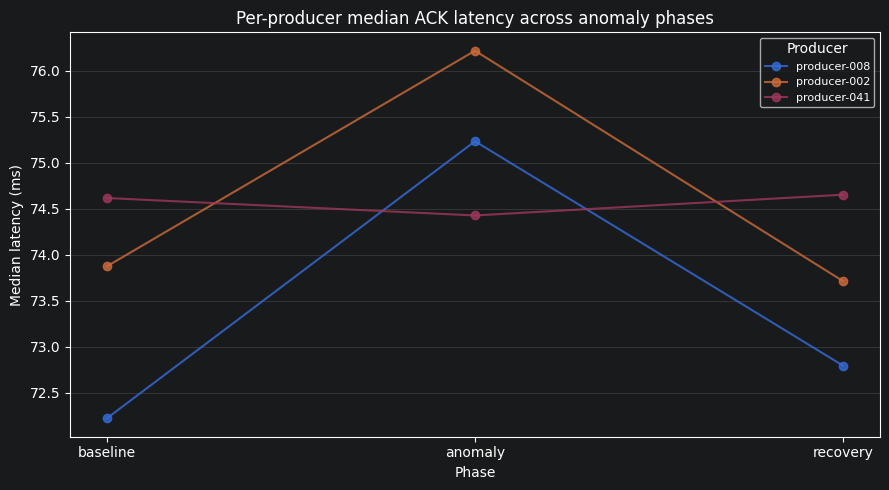

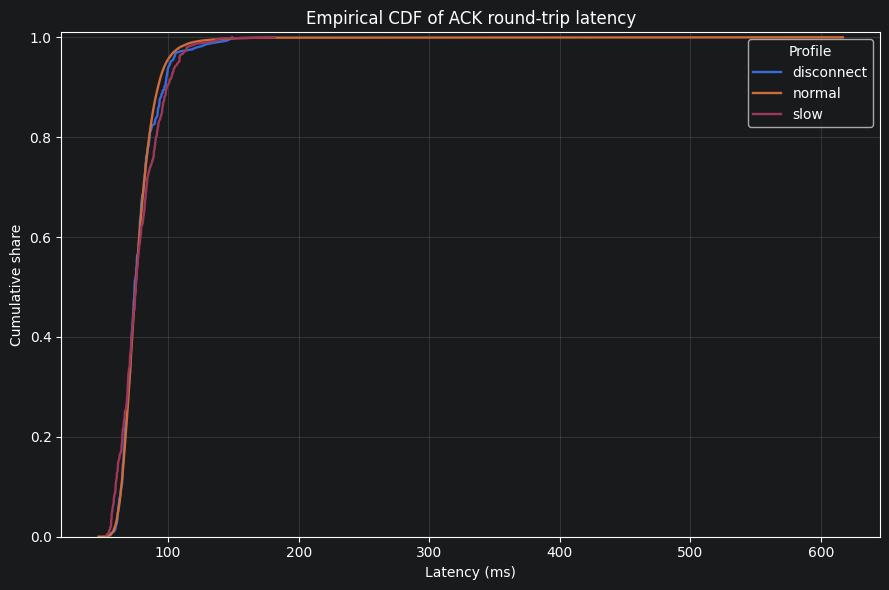

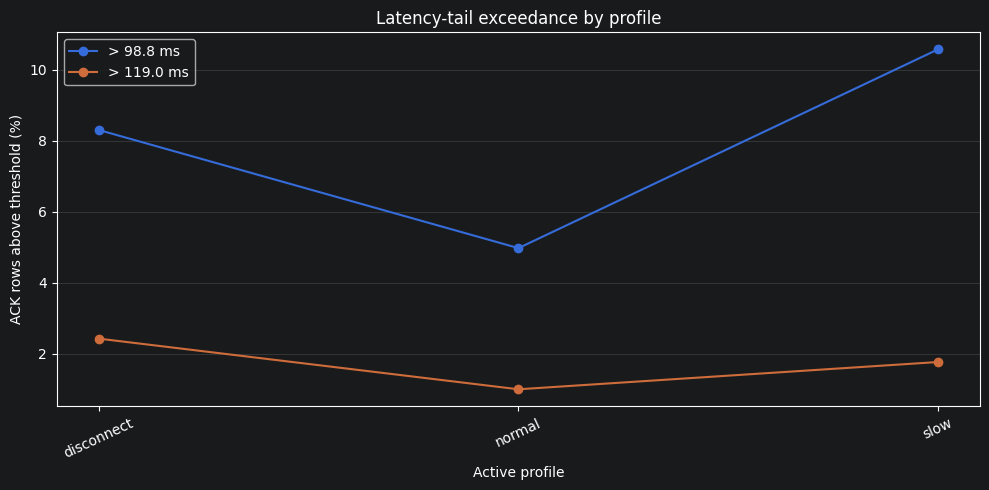

In [29]:
# Per-anomaly-producer phase medians show paired changes without pooling producer identities.
if not paired.empty:
    plot_phases = [phase for phase in ("baseline", "anomaly", "recovery") if paired[phase].notna().any()]
    fig, ax = plt.subplots(figsize=(9, 5))
    for producer_id, row in paired.iterrows():
        y = [row[phase] for phase in plot_phases]
        ax.plot(plot_phases, y, marker="o", linewidth=1.5, alpha=.8, label=producer_id)
    ax.set(title="Per-producer median ACK latency across anomaly phases", ylabel="Median latency (ms)", xlabel="Phase")
    ax.grid(axis="y", alpha=.25)
    ax.legend(title="Producer", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "paired_anomaly_phase_latency.png", dpi=180, bbox_inches="tight")
    plt.show()

# Empirical CDF by active profile exposes distribution shape and tail separation.
fig, ax = plt.subplots(figsize=(9, 6))
for profile, frame in events.groupby("profile", dropna=False):
    values = frame["latency_ms"].dropna().sort_values()
    if len(values):
        y = (range(1, len(values) + 1))
        ax.plot(values, [rank / len(values) for rank in y], label=str(profile), linewidth=1.7)
ax.set(title="Empirical CDF of ACK round-trip latency", xlabel="Latency (ms)", ylabel="Cumulative share")
ax.set_ylim(0, 1.01)
ax.grid(alpha=.25)
ax.legend(title="Profile")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_ecdf_by_profile.png", dpi=180, bbox_inches="tight")
plt.show()

# Tail exceedance by profile at the run's global P95 and P99.
if len(latency):
    report_thresholds = [latency.quantile(.95), latency.quantile(.99)]
    tail_plot = tail_exceedance[tail_exceedance["threshold_ms"].isin(report_thresholds)]
    if not tail_plot.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        for threshold, frame in tail_plot.groupby("threshold_ms"):
            ax.plot(frame["profile"], frame["share_above_pct"], marker="o", label=f"> {threshold:.1f} ms")
        ax.set(title="Latency-tail exceedance by profile", xlabel="Active profile", ylabel="ACK rows above threshold (%)")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=.25)
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "latency_tail_by_profile.png", dpi=180, bbox_inches="tight")
        plt.show()

## Figures

Figures are displayed inline and saved under the selected run’s `analysis/reports/<run_name>/` folder.

/var/folders/c7/qjcmr4c53vs74_zdhm2rf6g80000gn/T/ipykernel_25787/254616825.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(phase_groups, labels=phase_labels, showfliers=False)


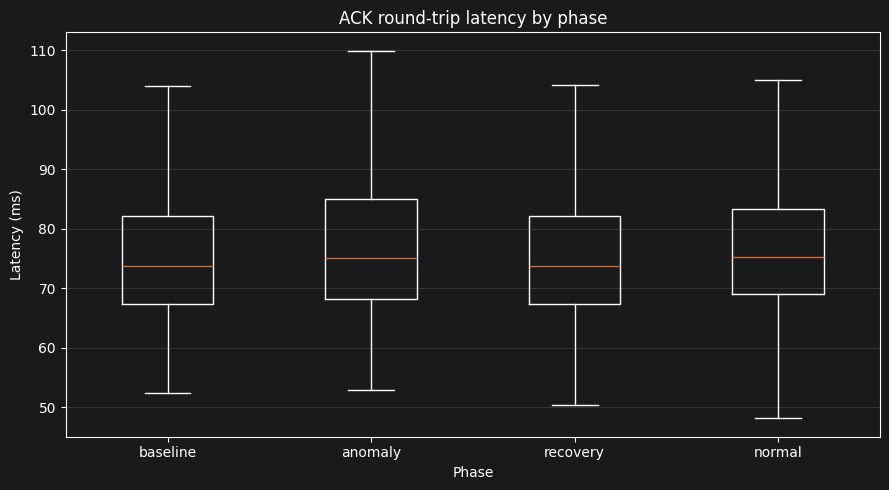

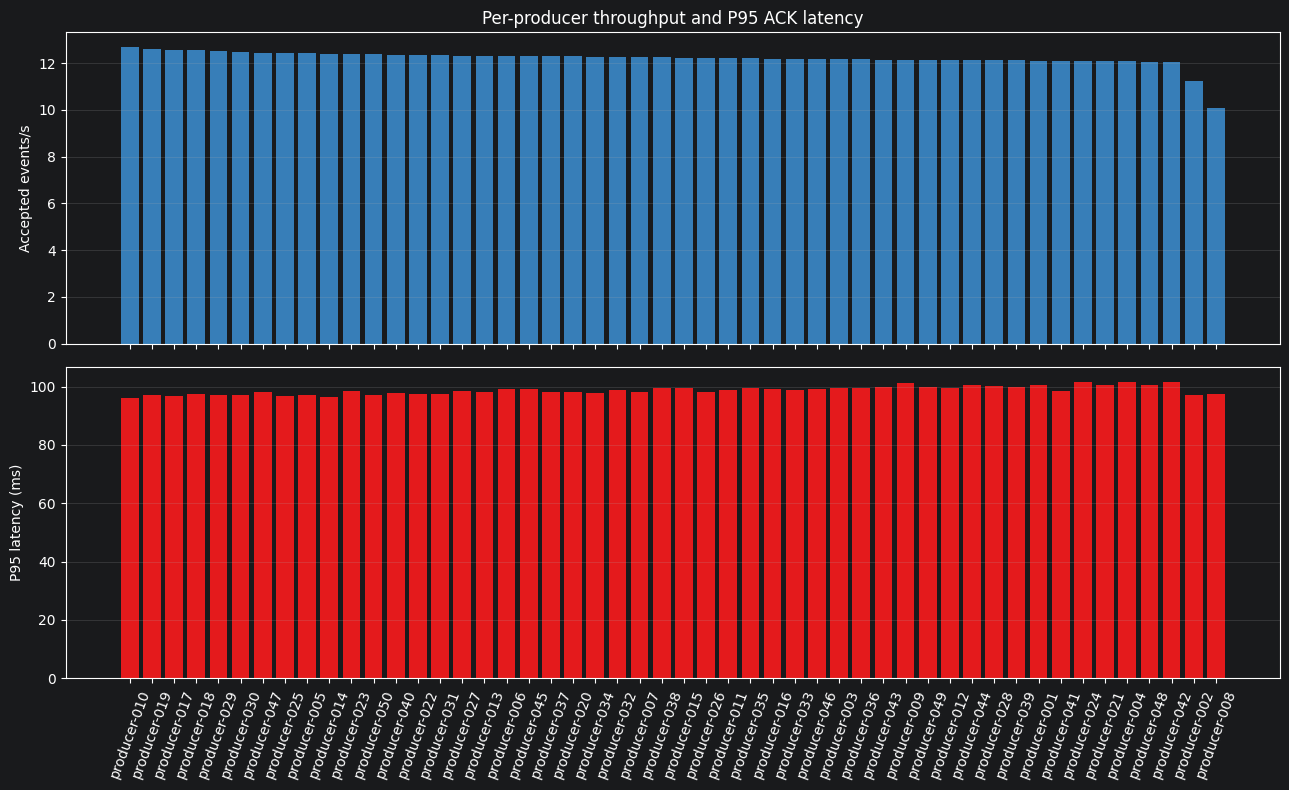

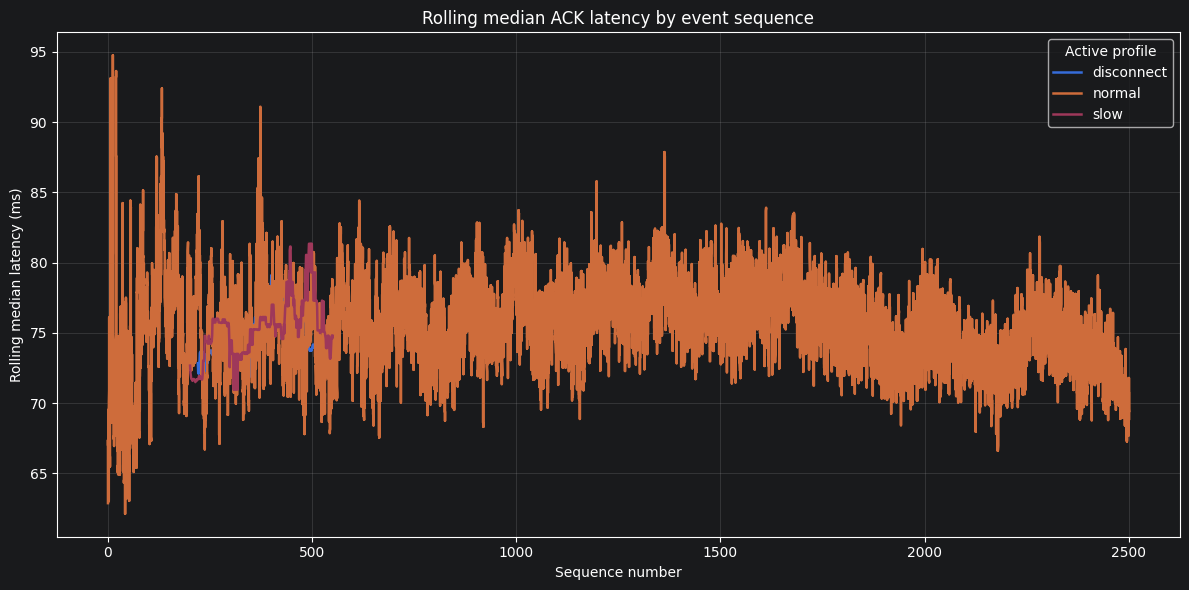

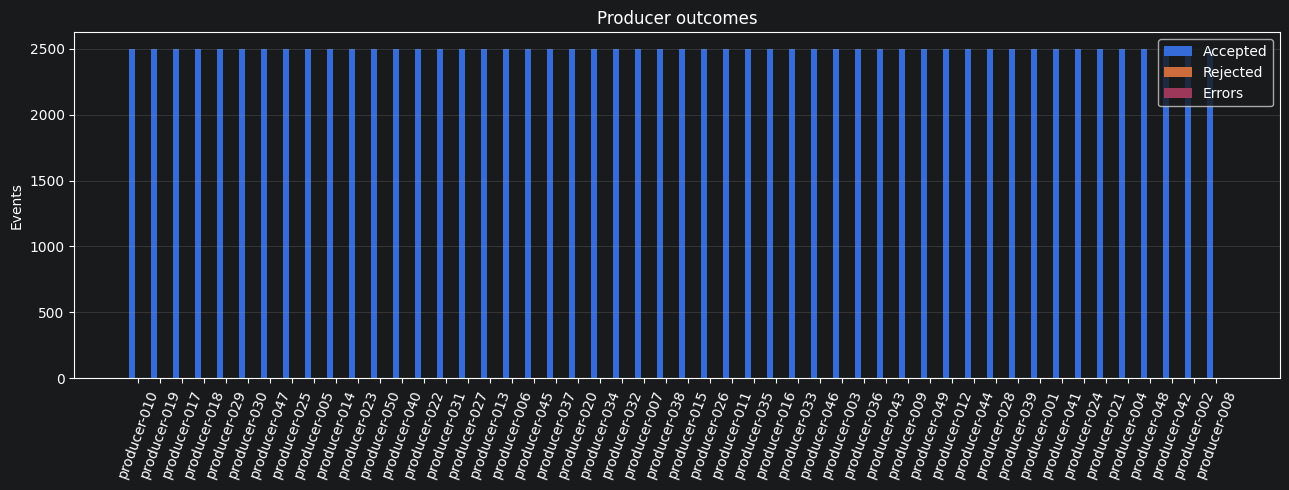

In [30]:
# ACK latency distributions by phase.
phase_groups = [events.loc[events["phase"] == phase, "latency_ms"].dropna() for phase in phase_order]
phase_labels = [phase for phase, values in zip(phase_order, phase_groups) if len(values)]
phase_groups = [values for values in phase_groups if len(values)]
if phase_groups:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(phase_groups, labels=phase_labels, showfliers=False)
    ax.set(title="ACK round-trip latency by phase", xlabel="Phase", ylabel="Latency (ms)")
    ax.grid(axis="y", alpha=.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "latency_by_phase.png", dpi=180, bbox_inches="tight")
    plt.show()

# Compare producer throughput and P95 latency.
plot_data = producer.sort_values("throughput_eps", ascending=False)
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].bar(plot_data["producer_id"], plot_data["throughput_eps"], color="#377eb8")
axes[0].set_ylabel("Accepted events/s")
axes[0].set_title("Per-producer throughput and P95 ACK latency")
axes[0].grid(axis="y", alpha=.25)
axes[1].bar(plot_data["producer_id"], plot_data["p95_ms"], color="#e41a1c")
axes[1].set_ylabel("P95 latency (ms)")
axes[1].tick_params(axis="x", rotation=70)
axes[1].grid(axis="y", alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "producer_throughput_and_p95.png", dpi=180, bbox_inches="tight")
plt.show()

# Event sequence trend by profile, using rolling medians to reduce point noise.
fig, ax = plt.subplots(figsize=(12, 6))
for profile, frame in events.groupby("profile", dropna=False):
    frame = frame.sort_values("seq")
    rolling = frame["latency_ms"].rolling(51, center=True, min_periods=10).median()
    ax.plot(frame["seq"], rolling, label=str(profile), linewidth=1.8)
ax.set(title="Rolling median ACK latency by event sequence", xlabel="Sequence number", ylabel="Rolling median latency (ms)")
ax.legend(title="Active profile")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_sequence_profile.png", dpi=180, bbox_inches="tight")
plt.show()

# Event counts and request errors by producer.
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(producer))
width = .28
ax.bar([v - width for v in x], producer["accepted"], width, label="Accepted")
ax.bar(x, producer["rejected"], width, label="Rejected")
ax.bar([v + width for v in x], producer["errors"], width, label="Errors")
ax.set_xticks(list(x), producer["producer_id"], rotation=70)
ax.set(title="Producer outcomes", ylabel="Events")
ax.legend()
ax.grid(axis="y", alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "producer_outcomes.png", dpi=180, bbox_inches="tight")
plt.show()

## Report-ready observations

This cell writes a concise Markdown summary alongside the figures. Review its statements against the tables and plots before using them in a report.

In [31]:
observations = [f"- Run `{RUN_DIR.name}` contains {producer['producer_id'].nunique()} producers and {len(latency):,} ACK-latency observations."]
if len(latency):
    observations.append(f"- Median ACK round-trip latency was {latency.median():.2f} ms; P95 was {latency.quantile(.95):.2f} ms and P99 was {latency.quantile(.99):.2f} ms.")
if ack_count:
    observations.append(f"- {accepted:,} of {ack_count:,} ACKed events were accepted ({100 * accepted / ack_count:.2f}%). Producer summaries also record {errors:,} errors.")
if "anomaly" in phase_stats.index and "baseline" in phase_stats.index and phase_stats.loc["baseline", "median_ms"]:
    ratio = phase_stats.loc["anomaly", "median_ms"] / phase_stats.loc["baseline", "median_ms"]
    observations.append(f"- Anomaly-phase median ACK latency was {ratio:.2f}× the baseline-phase median.")
if pd.notna(overall_jain_index):
    observations.append(f"- Jain’s index for observed per-producer throughput was {overall_jain_index:.3f}; this measures equality in this run, not scheduler fairness in general.")
if not paired.empty and paired["anomaly_change_pct"].notna().any():
    changes = paired["anomaly_change_pct"].dropna()
    observations.append(f"- Across {len(changes)} anomaly-assigned producer(s) with baseline and anomaly data, the median producer-level change in median latency was {changes.median():.2f}% (range {changes.min():.2f}% to {changes.max():.2f}%).")
if len(latency):
    p95 = latency.quantile(.95)
    observations.append(f"- {int((latency > p95).sum()):,} ACK observations were above the run-wide P95 value of {p95:.2f} ms; compare profile-level rates in the exceedance table.")
observations.append("- These latency values are client-observed ACK round-trip times, not ClickHouse insert latency. ACKs indicate WAL persistence and queue admission.")
report_text = "# FairGate benchmark report notes\n\n" + "\n".join(observations) + "\n"
print(report_text)
(OUTPUT_DIR / "report_notes.md").write_text(report_text, encoding="utf-8")
print(f"Saved figures and report notes to {OUTPUT_DIR}")

# FairGate benchmark report notes

- Run `run_20261005_193123` contains 50 producers and 125,000 ACK-latency observations.
- Median ACK round-trip latency was 75.16 ms; P95 was 98.81 ms and P99 was 118.96 ms.
- 125,000 of 125,000 ACKed events were accepted (100.00%). Producer summaries also record 0 errors.
- Anomaly-phase median ACK latency was 1.02× the baseline-phase median.
- Jain’s index for observed per-producer throughput was 0.999; this measures equality in this run, not scheduler fairness in general.
- Across 3 anomaly-assigned producer(s) with baseline and anomaly data, the median producer-level change in median latency was 3.17% (range -0.25% to 4.17%).
- 6,250 ACK observations were above the run-wide P95 value of 98.81 ms; compare profile-level rates in the exceedance table.
- These latency values are client-observed ACK round-trip times, not ClickHouse insert latency. ACKs indicate WAL persistence and queue admission.

Saved figures and report notes to /Users/pratyush/Gola

## Interpretation cautions

- Compare runs only when workload settings in `run_config.json` are comparable. Anomaly profiles are randomly assigned when profile randomization is enabled.
- The event-latency CSV includes acknowledged frames. Pair latency results with rejected and error counts.
- The generator’s `throughput_eps` is calculated per producer using that producer’s elapsed run time.
- The fairness index is descriptive; it is not, by itself, proof of DRR fairness under other workloads.
- ClickHouse may receive replayed batches if the process crashes after insertion but before checkpoint commit; this benchmark does not measure storage delivery or exactly-once behavior.